# xBD Damage Segmentation: full reproducible experiment

This notebook reproduces the full experiment end-to-end:
1. Train 4 segmentation models (U-Net, BAFUNet, FusionUNet, ResUNet++) with shared ResNet34 ImageNet encoder
2. Run BAFUNet ablation over `aggre_depth ∈ {1, 2, 3}`
3. Evaluate all on test split
4. Build comparison tables, training curves, prediction grids, error analysis

**Prerequisite**: dataset is already prepared via `python -m src.data.prepare_xbd`.

Resume is supported: rerunning a cell after interruption picks up from the latest checkpoint.

## Setup

In [1]:
import os, sys, subprocess
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print(f"Working dir: {Path.cwd()}")

# Verify dataset is ready
manifest = Path("xbd_processed/manifest.json")
if not manifest.exists():
    raise SystemExit(
        "Dataset not found. Run preprocessing first:\n"
        "  python -m src.data.prepare_xbd --xbd-root ./train --output ./xbd_processed"
    )
print(f"Dataset OK: {manifest}")

Working dir: /Users/oleksandrpokhylenko/Projects/KPI/xdb-segmentation
Dataset OK: xbd_processed/manifest.json


## Run Helper

In [2]:
def run(cmd):
    print(f"\n>>> {' '.join(cmd)}")
    r = subprocess.run(cmd, cwd=str(ROOT))
    if r.returncode != 0:
        raise SystemExit(f"Command failed: {cmd}")

## Main Training

In [3]:
MAIN_CONFIGS = [
    "configs/unet.yaml",
    "configs/bafunet.yaml",
    "configs/fusion_unet.yaml",
    "configs/resunet_pp.yaml",
]
for cfg in MAIN_CONFIGS:
    run(["python", "-m", "src.training.train", "--config", cfg, "--resume", "auto"])


>>> python -m src.training.train --config configs/unet.yaml --resume auto
20:43:28 | INFO | Device: Apple MPS
20:43:28 | INFO | Run dir: checkpoints/unet_resnet34
20:43:28 | INFO | Train tiles: 3199  Val tiles: 655
20:43:28 | INFO | Model: unet_smp  trainable params: 24,436,369
20:43:28 | INFO | AMP: False
20:43:28 | INFO | Resuming from checkpoints/unet_resnet34/last.pt
20:43:28 | INFO |   start epoch=30  best_val_dice=0.5740  best_epoch=28
20:43:29 | INFO | Curves saved to checkpoints/unet_resnet34/curves.png
20:43:29 | INFO | Done. Best val Dice = 0.5740 at epoch 29

>>> python -m src.training.train --config configs/bafunet.yaml --resume auto
20:43:32 | INFO | Device: Apple MPS
20:43:32 | INFO | Run dir: checkpoints/bafunet_resnet34
20:43:32 | INFO | Train tiles: 3199  Val tiles: 655
20:43:32 | INFO | Model: bafunet  trainable params: 39,334,277
20:43:32 | INFO | AMP: False
20:43:32 | INFO | Resuming from checkpoints/bafunet_resnet34/last.pt
20:43:32 | INFO |   start epoch=30  best

20:45:48 | INFO |   train  loss=0.2220  dice=0.7330  iou=0.5852
20:45:48 | INFO |   val    loss=0.3556  dice=0.5530  iou=0.4357    (132.1s)
20:45:48 | INFO | Early stopping: no val Dice improvement for 7 epochs
20:45:49 | INFO | Curves saved to checkpoints/fusion_unet_resnet34/curves.png
20:45:49 | INFO | Done. Best val Dice = 0.5837 at epoch 13

>>> python -m src.training.train --config configs/resunet_pp.yaml --resume auto
20:46:12 | INFO | Device: Apple MPS
20:46:12 | INFO | Run dir: checkpoints/resunet_pp_resnet34
20:46:12 | INFO | Train tiles: 3199  Val tiles: 655
20:46:13 | INFO | Model: resunet_pp  trainable params: 26,281,332
20:46:13 | INFO | AMP: False
20:46:13 | INFO | Resuming from checkpoints/resunet_pp_resnet34/last.pt
20:46:13 | INFO |   start epoch=30  best_val_dice=0.5832  best_epoch=27
20:46:13 | INFO | Curves saved to checkpoints/resunet_pp_resnet34/curves.png
20:46:13 | INFO | Done. Best val Dice = 0.5832 at epoch 28


## Ablation

In [4]:
run(["python", "scripts/run_ablation.py"])


>>> python scripts/run_ablation.py

Ablation: aggre_depth=1
20:46:16 | INFO | Device: Apple MPS
20:46:16 | INFO | Run dir: checkpoints/bafunet_ablation_d1
20:46:16 | INFO | Train tiles: 3199  Val tiles: 655
20:46:17 | INFO | Model: bafunet  trainable params: 35,417,267
20:46:17 | INFO | AMP: False
20:46:17 | INFO | No checkpoint found, starting from scratch
20:46:17 | INFO | === Epoch 1/30 ===


20:47:48 | INFO |   train  loss=0.6935  dice=0.4641  iou=0.3246
20:47:48 | INFO |   val    loss=0.6634  dice=0.3181  iou=0.2095  (best)  (91.4s)
20:47:48 | INFO | === Epoch 2/30 ===


20:49:09 | INFO |   train  loss=0.6200  dice=0.5880  iou=0.4294
20:49:09 | INFO |   val    loss=0.6160  dice=0.4235  iou=0.3054  (best)  (81.3s)
20:49:09 | INFO | === Epoch 3/30 ===


20:50:30 | INFO |   train  loss=0.5838  dice=0.5811  iou=0.4236
20:50:30 | INFO |   val    loss=0.5984  dice=0.3637  iou=0.2464    (80.3s)
20:50:30 | INFO | === Epoch 4/30 ===


20:51:52 | INFO |   train  loss=0.5513  dice=0.5790  iou=0.4204
20:51:52 | INFO |   val    loss=0.5681  dice=0.4241  iou=0.3024  (best)  (82.0s)
20:51:52 | INFO | === Epoch 5/30 ===


...

22:51:40 | INFO |   train  loss=0.4294  dice=0.6346  iou=0.4761
22:51:40 | INFO |   val    loss=0.4755  dice=0.5028  iou=0.3739    (117.5s)
22:51:40 | INFO | === Epoch 10/30 ===


22:53:39 | INFO |   train  loss=0.4073  dice=0.6351  iou=0.4775
22:53:39 | INFO |   val    loss=0.4638  dice=0.5142  iou=0.3902    (118.9s)
22:53:39 | INFO | === Epoch 11/30 ===


22:55:38 | INFO |   train  loss=0.3833  dice=0.6543  iou=0.4977
22:55:38 | INFO |   val    loss=0.4524  dice=0.5130  iou=0.3979    (118.8s)
22:55:38 | INFO | Early stopping: no val Dice improvement for 7 epochs
22:55:39 | INFO | Curves saved to checkpoints/bafunet_ablation_d3/curves.png
22:55:39 | INFO | Done. Best val Dice = 0.5171 at epoch 4
22:56:02 | INFO | Device: Apple MPS
22:56:02 | INFO | test tiles: 714
22:56:03 | INFO | Loading checkpoints/bafunet_ablation_d3/best.pt
22:56:03 | INFO |   ckpt epoch=3  best_val_dice=0.5171


eval: 100%|██████████| 45/45 [00:21<00:00,  2.10it/s]



=== bafunet_ablation_d3 on test ===
  dice           0.5268
  iou            0.4020
  pixel_acc      0.9807
  precision      0.5467
  recall         0.6524
  loss           0.5622
22:56:25 | INFO | Saved checkpoints/bafunet_ablation_d3/test_metrics.json


## Evaluate All

In [5]:
ALL_CONFIGS = MAIN_CONFIGS + [
    f"configs/_ablation/bafunet_ablation_d{d}.yaml" for d in [1, 2, 3]
]
for cfg in ALL_CONFIGS:
    run(["python", "scripts/evaluate.py", "--config", cfg])


>>> python scripts/evaluate.py --config configs/unet.yaml
22:56:28 | INFO | Device: Apple MPS
22:56:28 | INFO | test tiles: 714
22:56:28 | INFO | Loading checkpoints/unet_resnet34/best.pt
22:56:28 | INFO |   ckpt epoch=28  best_val_dice=0.5740


eval: 100%|██████████| 45/45 [00:18<00:00,  2.48it/s]



=== unet_resnet34 on test ===
  dice           0.5803
  iou            0.4636
  pixel_acc      0.9876
  precision      0.7086
  recall         0.5894
  loss           0.2833
22:56:46 | INFO | Saved checkpoints/unet_resnet34/test_metrics.json

>>> python scripts/evaluate.py --config configs/bafunet.yaml
22:56:49 | INFO | Device: Apple MPS
22:56:49 | INFO | test tiles: 714
22:56:50 | INFO | Loading checkpoints/bafunet_resnet34/best.pt
22:56:50 | INFO |   ckpt epoch=26  best_val_dice=0.6127


eval: 100%|██████████| 45/45 [00:20<00:00,  2.20it/s]



=== bafunet_resnet34 on test ===
  dice           0.6402
  iou            0.5161
  pixel_acc      0.9881
  precision      0.7021
  recall         0.6306
  loss           0.2836
22:57:10 | INFO | Saved checkpoints/bafunet_resnet34/test_metrics.json

>>> python scripts/evaluate.py --config configs/fusion_unet.yaml
22:57:14 | INFO | Device: Apple MPS
22:57:14 | INFO | test tiles: 714
22:57:14 | INFO | Loading checkpoints/fusion_unet_resnet34/best.pt
22:57:14 | INFO |   ckpt epoch=12  best_val_dice=0.5837


...


=== bafunet_ablation_d1 on test ===
  dice           0.6089
  iou            0.4849
  pixel_acc      0.9876
  precision      0.6832
  recall         0.6334
  loss           0.3230
22:58:31 | INFO | Saved checkpoints/bafunet_ablation_d1/test_metrics.json

>>> python scripts/evaluate.py --config configs/_ablation/bafunet_ablation_d2.yaml
22:58:34 | INFO | Device: Apple MPS
22:58:34 | INFO | test tiles: 714
22:58:35 | INFO | Loading checkpoints/bafunet_ablation_d2/best.pt
22:58:35 | INFO |   ckpt epoch=26  best_val_dice=0.6127


eval: 100%|██████████| 45/45 [00:20<00:00,  2.22it/s]



=== bafunet_ablation_d2 on test ===
  dice           0.6402
  iou            0.5161
  pixel_acc      0.9881
  precision      0.7021
  recall         0.6306
  loss           0.2836
22:58:55 | INFO | Saved checkpoints/bafunet_ablation_d2/test_metrics.json

>>> python scripts/evaluate.py --config configs/_ablation/bafunet_ablation_d3.yaml
22:58:58 | INFO | Device: Apple MPS
22:58:58 | INFO | test tiles: 714
22:58:59 | INFO | Loading checkpoints/bafunet_ablation_d3/best.pt
22:58:59 | INFO |   ckpt epoch=3  best_val_dice=0.5171


eval: 100%|██████████| 45/45 [00:20<00:00,  2.16it/s]



=== bafunet_ablation_d3 on test ===
  dice           0.5268
  iou            0.4020
  pixel_acc      0.9807
  precision      0.5467
  recall         0.6524
  loss           0.5622
22:59:20 | INFO | Saved checkpoints/bafunet_ablation_d3/test_metrics.json


## Main Comparison Table

In [6]:
import pandas as pd
import json

MAIN_RUNS = {
    "U-Net": "unet_resnet34",
    "BAFUNet": "bafunet_resnet34",
    "FusionUNet": "fusion_unet_resnet34",
    "ResUNet++": "resunet_pp_resnet34",
}
rows = []
for label, run_name in MAIN_RUNS.items():
    metrics = json.load(open(Path("checkpoints") / run_name / "test_metrics.json"))["metrics"]
    rows.append({"model": label, **{k: round(v, 4) for k, v in metrics.items()}})
df_main = pd.DataFrame(rows).sort_values("dice", ascending=False).reset_index(drop=True)
df_main.to_csv("results/main_comparison.csv", index=False)
df_main

,model,dice,iou,pixel_acc,precision,recall,loss
0,BAFUNet,0.6402,0.5161,0.9881,0.7021,0.6306,0.2836
1,U-Net,0.5803,0.4636,0.9876,0.7086,0.5894,0.2833
2,ResUNet++,0.5793,0.4639,0.9874,0.7244,0.5979,0.2832
3,FusionUNet,0.5268,0.4019,0.9835,0.4870,0.7023,0.3898


## Training Curves Comparison

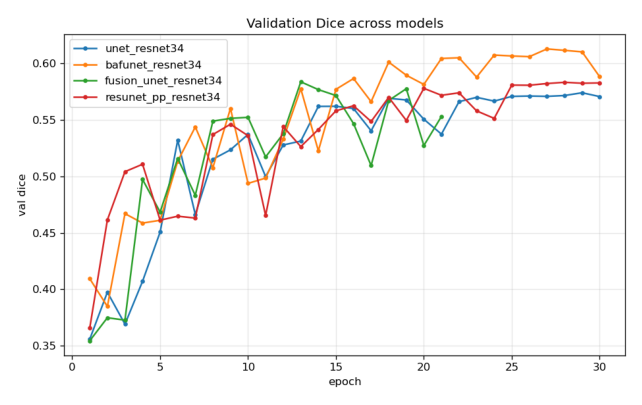

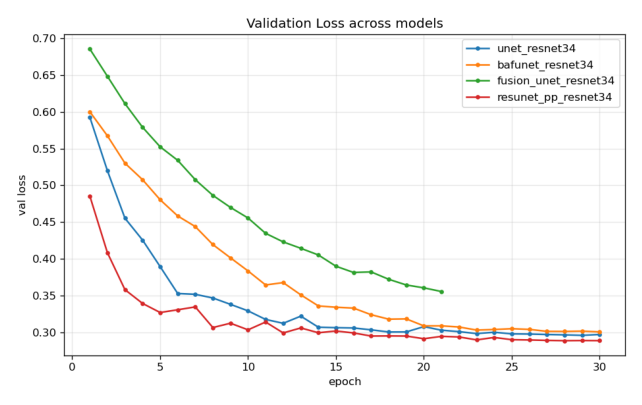

In [7]:
from src.training.plots import plot_compare_runs

results_dir = Path("results"); results_dir.mkdir(exist_ok=True)
run_dirs = [Path("checkpoints") / r for r in MAIN_RUNS.values()]
plot_compare_runs(run_dirs, results_dir / "compare_val_dice.png", metric="dice", split="val",
                  title="Validation Dice across models")
plot_compare_runs(run_dirs, results_dir / "compare_val_loss.png", metric="loss", split="val",
                  title="Validation Loss across models")

from PIL import Image
import matplotlib.pyplot as plt
for p in [results_dir / "compare_val_dice.png", results_dir / "compare_val_loss.png"]:
    plt.figure(figsize=(10, 5))
    plt.imshow(Image.open(p)); plt.axis("off"); plt.show()

## Ablation Table

In [8]:
ablation_rows = []
for d in [1, 2, 3]:
    rn = f"bafunet_ablation_d{d}"
    metrics = json.load(open(Path("checkpoints") / rn / "test_metrics.json"))["metrics"]
    ablation_rows.append({"aggre_depth": d, **{k: round(v, 4) for k, v in metrics.items()}})
df_abl = pd.DataFrame(ablation_rows)
df_abl.to_csv("results/ablation.csv", index=False)
df_abl

,aggre_depth,dice,iou,pixel_acc,precision,recall,loss
0,1,0.6089,0.4849,0.9876,0.6832,0.6334,0.3230
1,2,0.6402,0.5161,0.9881,0.7021,0.6306,0.2836
2,3,0.5268,0.4020,0.9807,0.5467,0.6524,0.5622


## Visualize Predictions for Best Model


>>> python scripts/visualize_predictions.py --config configs/bafunet.yaml --output results/predictions_grid.png --n-samples 12 --strategy mixed
Saved results/predictions_grid.png


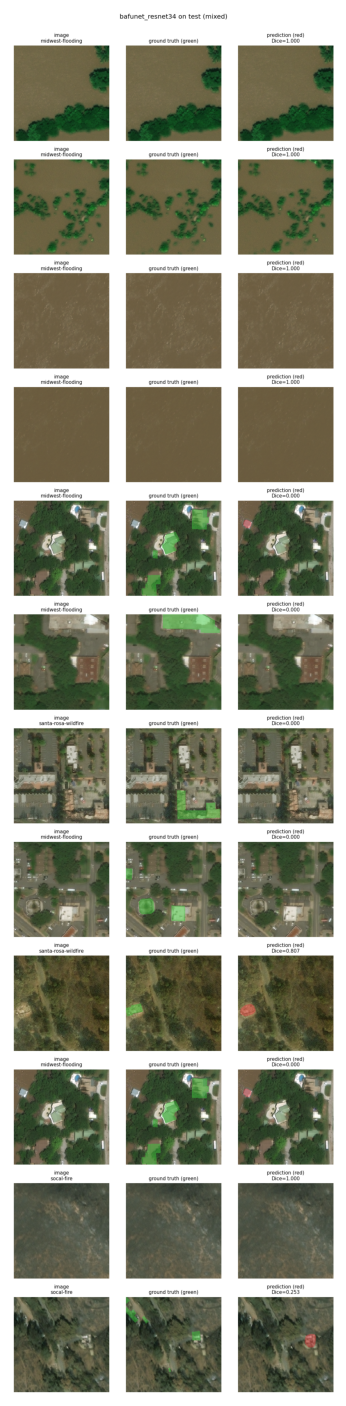

In [9]:
best_run = df_main.iloc[0]["model"]
best_cfg = {v: f"configs/{Path(v).name}" for v in MAIN_RUNS.values()}
# pick config matching best run
best_run_name = MAIN_RUNS[best_run]
best_config = next(c for c in MAIN_CONFIGS if best_run_name in str(c) or Path(c).stem in best_run_name)
# fallback by mapping
config_for_run = {
    "unet_resnet34": "configs/unet.yaml",
    "bafunet_resnet34": "configs/bafunet.yaml",
    "fusion_unet_resnet34": "configs/fusion_unet.yaml",
    "resunet_pp_resnet34": "configs/resunet_pp.yaml",
}
best_config = config_for_run[best_run_name]

run(["python", "scripts/visualize_predictions.py",
     "--config", best_config,
     "--output", "results/predictions_grid.png",
     "--n-samples", "12", "--strategy", "mixed"])

plt.figure(figsize=(12, 18))
plt.imshow(Image.open("results/predictions_grid.png")); plt.axis("off"); plt.show()

## Error Analysis


>>> python scripts/error_analysis.py --config configs/unet.yaml --output-dir results/errors_unet_resnet34

=== By disaster (positive tiles only for Dice/IoU) ===
           disaster  n_positive  mean_dice  median_dice  mean_iou  n_empty  mean_fpr
   midwest-flooding          26     0.2221       0.0000    0.1806       89  0.000309
santa-rosa-wildfire         164     0.7044       0.7734    0.5760       59  0.000562
         socal-fire          88     0.5091       0.6840    0.4006      288  0.000186

Total: 714 tiles (278 positive + 436 empty)
Saved analysis to results/errors_unet_resnet34

>>> python scripts/error_analysis.py --config configs/bafunet.yaml --output-dir results/errors_bafunet_resnet34

=== By disaster (positive tiles only for Dice/IoU) ===
           disaster  n_positive  mean_dice  median_dice  mean_iou  n_empty  mean_fpr
   midwest-flooding          26     0.2677       0.0000    0.2122       89  0.000518
santa-rosa-wildfire         164     0.7107       0.7812    0.5835 

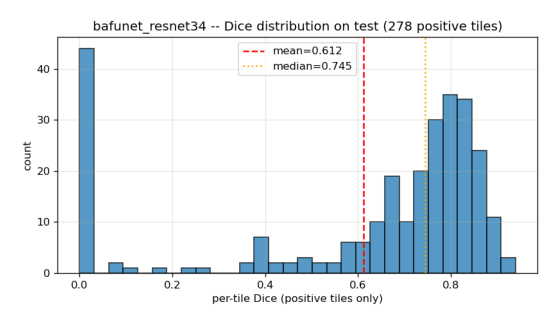

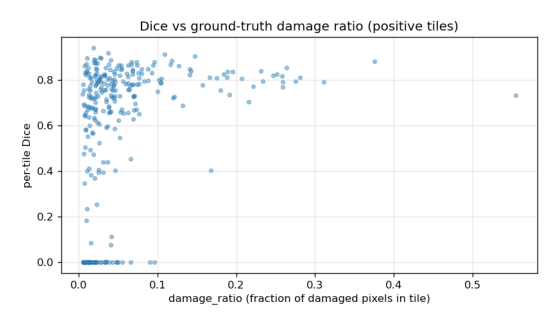

In [12]:
for run_name in MAIN_RUNS.values():
    cfg = config_for_run[run_name]
    run(["python", "scripts/error_analysis.py",
         "--config", cfg,
         "--output-dir", f"results/errors_{run_name}"])

# Show histograms for best model
err_dir = Path(f"results/errors_{best_run_name}")
plt.figure(figsize=(8, 4))
plt.imshow(Image.open(err_dir / "dice_distribution.png")); plt.axis("off"); plt.show()
plt.figure(figsize=(8, 4))
plt.imshow(Image.open(err_dir / "dice_vs_damage_ratio.png")); plt.axis("off"); plt.show()

## Final Summary

In [13]:
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print("\nMain comparison (test split):")
print(df_main.to_string(index=False))
print("\nBAFUNet ablation:")
print(df_abl.to_string(index=False))
print("\nResults saved to: results/")
print("  - main_comparison.csv, ablation.csv")
print("  - compare_val_dice.png, compare_val_loss.png")
print("  - predictions_grid.png")
print("  - errors_<run>/dice_distribution.png, dice_vs_damage_ratio.png, by_disaster.csv")

FINAL SUMMARY

Main comparison (test split):
     model   dice    iou  pixel_acc  precision  recall   loss
   BAFUNet 0.6402 0.5161     0.9881     0.7021  0.6306 0.2836
     U-Net 0.5803 0.4636     0.9876     0.7086  0.5894 0.2833
 ResUNet++ 0.5793 0.4639     0.9874     0.7244  0.5979 0.2832
FusionUNet 0.5268 0.4019     0.9835     0.4870  0.7023 0.3898

BAFUNet ablation:
 aggre_depth   dice    iou  pixel_acc  precision  recall   loss
           1 0.6089 0.4849     0.9876     0.6832  0.6334 0.3230
           2 0.6402 0.5161     0.9881     0.7021  0.6306 0.2836
           3 0.5268 0.4020     0.9807     0.5467  0.6524 0.5622

Results saved to: results/
  - main_comparison.csv, ablation.csv
  - compare_val_dice.png, compare_val_loss.png
  - predictions_grid.png
  - errors_<run>/dice_distribution.png, dice_vs_damage_ratio.png, by_disaster.csv
